In [1]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install Rdkit

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
!{sys.executable} -m pip install xgboost

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold, StratifiedKFold
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
import math
from xgboost import XGBRegressor

In [6]:
import os

print(os.listdir("/Users/favour/Desktop/untitled folder/dataset"))

['hansen_h_bert_ds5.csv', 'hansen_p_bert_ds6.csv', 'hansen_h_bert_ds4.csv', 'hansen_h_bert_ds6.csv', 'hansen_p_bert_ds5.csv', 'hansen_p_bert_ds4.csv', 'hansen_h_bert_ds3.csv', 'hansen_p_bert_ds1.csv', 'hansen_h_bert_ds2.csv', 'hansen_p_bert_ds3.csv', 'hansen_p_bert_ds2.csv', 'hansen_h_bert_ds1.csv', 'hansen_1k_smiles_shorter.csv', 'hansen_d_bert_ds6.csv', 'hansen_d_bert_ds5.csv', 'esol.csv', 'hansen_d_bert_ds4.csv', 'hansen_d_bert_ds1.csv', 'hansen_d_bert_ds3.csv', 'hansen_d_bert_ds2.csv', 'esol_bert_ds2.csv', 'esol_bert_ds3.csv', 'esol_bert_ds1.csv', 'esol_bert_ds4.csv', 'esol_bert_ds5.csv', 'esol_bert_ds6.csv']


In [7]:
# Reading Esol and SMILES data

esol_data = pd.read_csv('/Users/favour/Desktop/untitled folder/dataset/esol.csv')
mol_smiles = esol_data['SMILES']
log_s = esol_data['measured log(solubility:mol/L)']
esol_data['number'] = esol_data.index
mol_number = esol_data['number']
mol_name = esol_data['Compound ID']

In [8]:
# generate fingeprints: Morgan fingerprint with radius 8 and 2048 nBits
fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(x), 8, nBits=2048) for x in esol_data['SMILES']]
#convert fps into numpy array
np_fps = np.asarray(fps)
np_fps.shape

# generate MACCS fingerprints
#maccs_fps = [MACCSkeys.GenMACCSKeys (Chem.MolFromSmiles(x)) for x in gpHSP_data['smiles']]

[03:54:18] DEPRECATION WARNING: please use MorganGenerator
[03:54:18] DEPRECATION WARNING: please use MorganGenerator
[03:54:18] DEPRECATION WARNING: please use MorganGenerator
[03:54:18] DEPRECATION WARNING: please use MorganGenerator
[03:54:18] DEPRECATION WARNING: please use MorganGenerator
[03:54:18] DEPRECATION WARNING: please use MorganGenerator
[03:54:18] DEPRECATION WARNING: please use MorganGenerator
[03:54:18] DEPRECATION WARNING: please use MorganGenerator
[03:54:18] DEPRECATION WARNING: please use MorganGenerator
[03:54:18] DEPRECATION WARNING: please use MorganGenerator
[03:54:18] DEPRECATION WARNING: please use MorganGenerator
[03:54:18] DEPRECATION WARNING: please use MorganGenerator
[03:54:18] DEPRECATION WARNING: please use MorganGenerator
[03:54:18] DEPRECATION WARNING: please use MorganGenerator
[03:54:18] DEPRECATION WARNING: please use MorganGenerator
[03:54:18] DEPRECATION WARNING: please use MorganGenerator
[03:54:18] DEPRECATION WARNING: please use MorganGenerat

(1144, 2048)

Fold:1, Train set: 953, Test set:191
0.8314747248104728
1.1225961916230005
0.7136964872422931


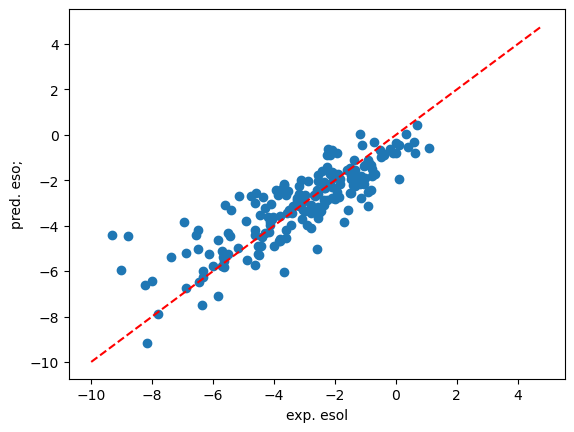

Fold:2, Train set: 953, Test set:191
0.8140763888529535
1.0973893521651803
0.7113962055168073


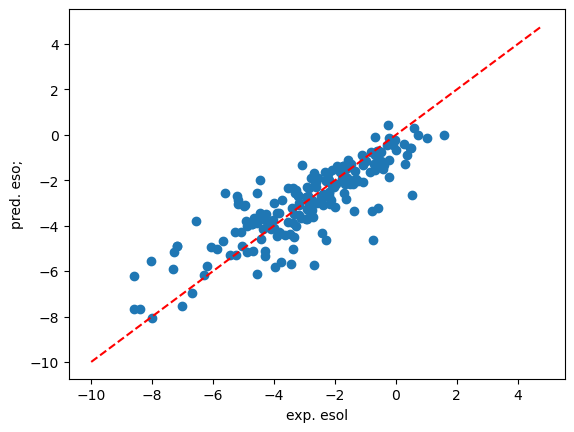

Fold:3, Train set: 953, Test set:191
0.7949387552338745
1.0353543555310945
0.7434720420730434


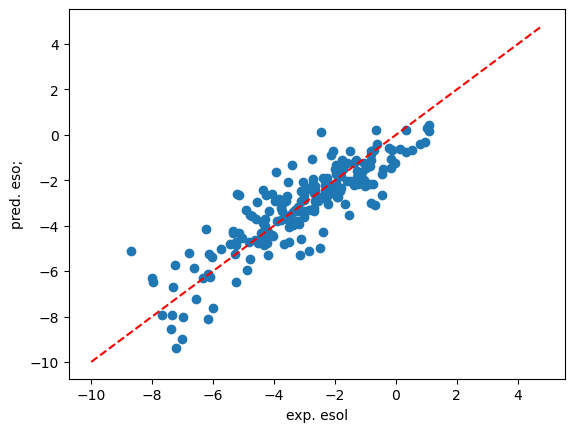

Fold:4, Train set: 953, Test set:191
0.8293407902505385
1.1151592299625386
0.7384626546781712


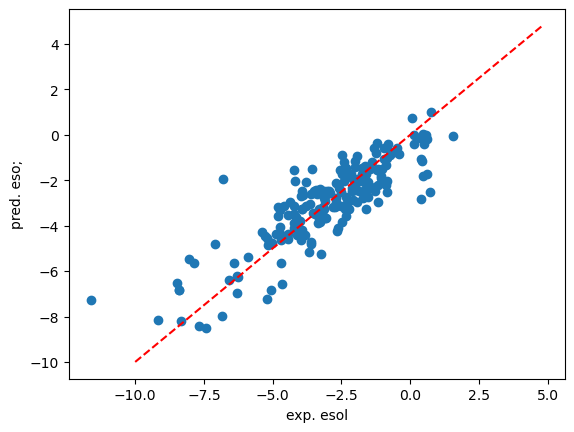

Fold:5, Train set: 954, Test set:190
0.7734662628995744
1.022084842752866
0.7723052063462105


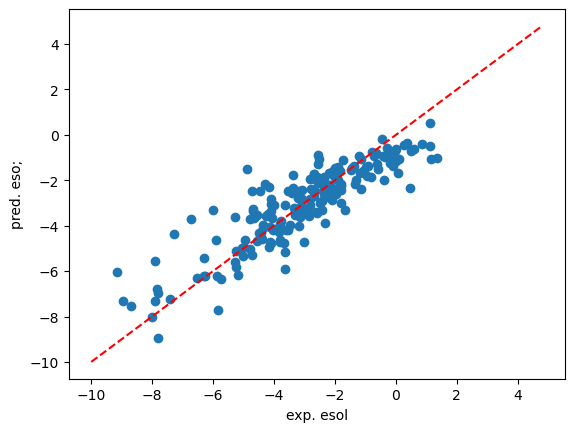

Fold:6, Train set: 954, Test set:190
0.8996410235797104
1.1836401563365533
0.6635556447060189


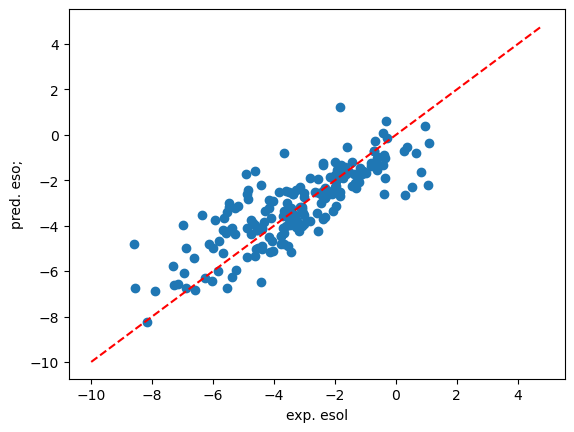

In [9]:
# split the data into 6 folds.  
# use'kf'(KFold splitting stratergy) object as input to cross_val_score() method
kf =KFold(n_splits=6, shuffle=True, random_state=42)

# initial fold number
cnt = 1

# split()  method generate indices to split data into training and test set.
for train_index, test_index in kf.split(np_fps, log_s):
    print(f'Fold:{cnt}, Train set: {len(train_index)}, Test set:{len(test_index)}')
  
    fps_train, fps_test = np_fps[train_index], np_fps[test_index]
    esol_train, esol_test = log_s[train_index], log_s[test_index]
    index_train, index_test = mol_number[train_index], mol_number[test_index]
    smiles_train, smiles_test = mol_smiles[train_index], mol_smiles[test_index]
    
    # training model
    model = XGBRegressor().fit(fps_train, esol_train)
    esol_pred = model.predict(fps_test)
    
    # print out MAE, RMSE and R2
    print(mean_absolute_error (esol_test, esol_pred))
    print(math.sqrt(mean_squared_error(esol_test, esol_pred)))
    print(r2_score (esol_test, esol_pred))
    
    # convert predictions into df and concat molecules' index, SMILES, exp and predicted values 
    # and save into a csv file for each fold
    pd_esol_pred = pd.DataFrame(esol_pred, columns=["pred"])
    # uncertainty from XGBOOST 
    #pd_esol_dists = pd.DataFrame(esol_dists, columns=["dists"])
    xg_output = pd.concat((index_test.reset_index(), smiles_test.reset_index(), esol_test.reset_index(), pd_esol_pred), ignore_index=True, axis=1)
    xg_output.to_csv(f'fps_xgboost_esol_total_fold_{cnt}.csv')

    # plot exp vs predicted values
    ln = np.arange(-10, 5, 0.2)
    plt.plot(ln, ln,'r--')
    plt.scatter(esol_test, esol_pred)
    plt.plot(color='green')

    plt.xlabel('exp. esol')
    plt.ylabel('pred. eso;')
    plt.show()
    
    cnt += 1
    

Fold:1, Train set: 953, Test set:191
MAE  : 0.8315
RMSE : 1.1226
R2   : 0.7137


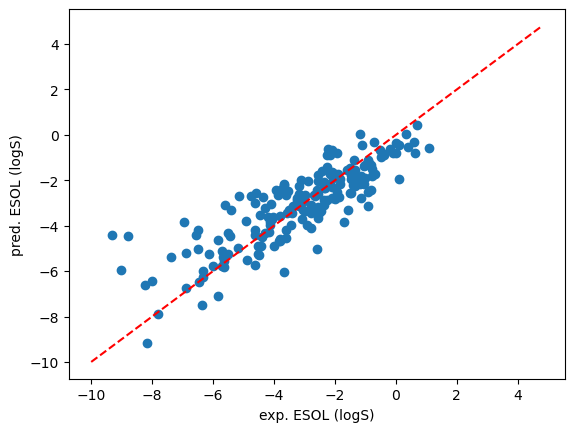

Fold:2, Train set: 953, Test set:191
MAE  : 0.8141
RMSE : 1.0974
R2   : 0.7114


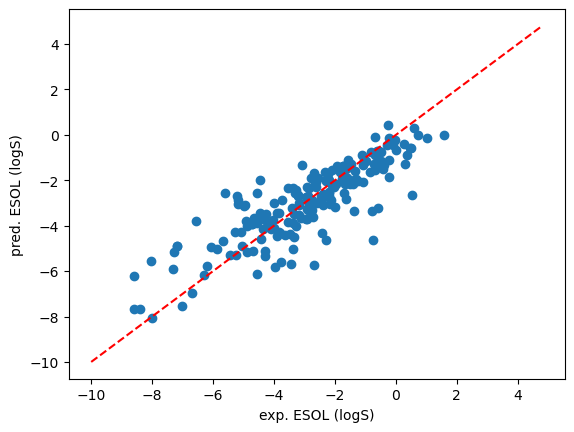

Fold:3, Train set: 953, Test set:191
MAE  : 0.7949
RMSE : 1.0354
R2   : 0.7435


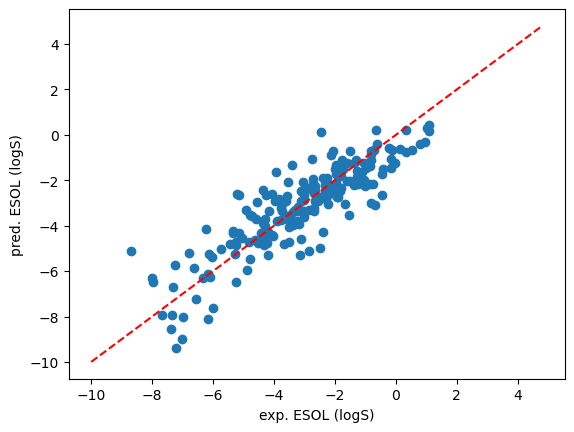

Fold:4, Train set: 953, Test set:191
MAE  : 0.8293
RMSE : 1.1152
R2   : 0.7385


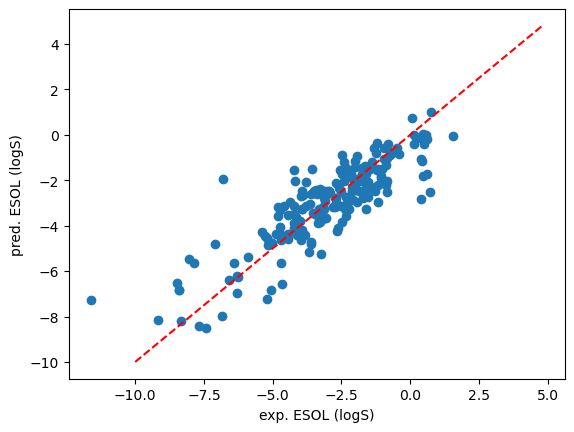

Fold:5, Train set: 954, Test set:190
MAE  : 0.7735
RMSE : 1.0221
R2   : 0.7723


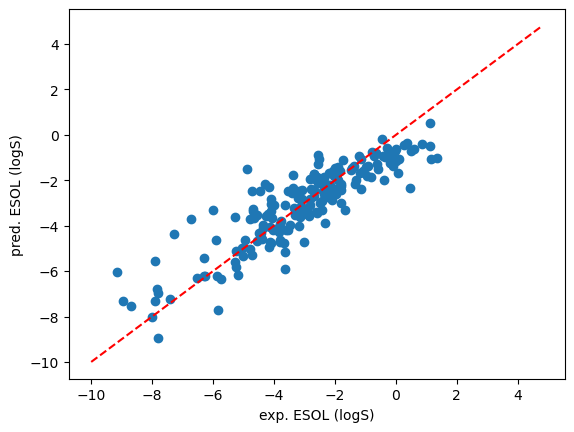

Fold:6, Train set: 954, Test set:190
MAE  : 0.8996
RMSE : 1.1836
R2   : 0.6636


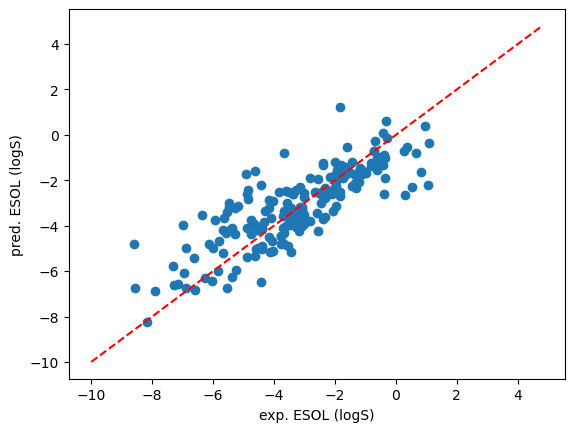


=== 6-Fold CV Summary (ESOL) ===
MAE  : 0.8238 ± 0.0431
RMSE : 1.0960 ± 0.0598
R2   : 0.7238 ± 0.0370


In [10]:
import numpy as np
import pandas as pd
import math
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

kf = KFold(n_splits=6, shuffle=True, random_state=42)

# store metrics
mae_scores = []
rmse_scores = []
r2_scores = []

cnt = 1

for train_index, test_index in kf.split(np_fps, log_s):
    print(f'Fold:{cnt}, Train set: {len(train_index)}, Test set:{len(test_index)}')

    fps_train, fps_test = np_fps[train_index], np_fps[test_index]
    esol_train, esol_test = log_s[train_index], log_s[test_index]
    index_test = mol_number[test_index]
    smiles_test = mol_smiles[test_index]

    # train model
    model = XGBRegressor()
    model.fit(fps_train, esol_train)
    esol_pred = model.predict(fps_test)

    # calculate metrics
    fold_mae = mean_absolute_error(esol_test, esol_pred)
    fold_rmse = math.sqrt(mean_squared_error(esol_test, esol_pred))
    fold_r2 = r2_score(esol_test, esol_pred)

    # store metrics
    mae_scores.append(fold_mae)
    rmse_scores.append(fold_rmse)
    r2_scores.append(fold_r2)

    # print fold metrics
    print(f"MAE  : {fold_mae:.4f}")
    print(f"RMSE : {fold_rmse:.4f}")
    print(f"R2   : {fold_r2:.4f}")

    # save predictions
    out_df = pd.DataFrame({
        "Mol_No": index_test,
        "SMILES": smiles_test,
        "actual": esol_test,
        "predict": esol_pred
    })

    out_df.to_csv(f'fps_xgboost_esol_total_fold_{cnt}.csv', index=False)

    # plot exp vs predicted
    ln = np.arange(-10, 5, 0.2)
    plt.plot(ln, ln, 'r--')
    plt.scatter(esol_test, esol_pred)
    plt.xlabel('exp. ESOL (logS)')
    plt.ylabel('pred. ESOL (logS)')
    plt.show()

    cnt += 1

# Convert to arrays
mae_scores = np.array(mae_scores)
rmse_scores = np.array(rmse_scores)
r2_scores = np.array(r2_scores)

# Print CV summary
print("\n=== 6-Fold CV Summary (ESOL) ===")
print(f"MAE  : {mae_scores.mean():.4f} ± {mae_scores.std(ddof=1):.4f}")
print(f"RMSE : {rmse_scores.mean():.4f} ± {rmse_scores.std(ddof=1):.4f}")
print(f"R2   : {r2_scores.mean():.4f} ± {r2_scores.std(ddof=1):.4f}")

In [11]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools
from rdkit.Chem.Draw import IPythonConsole
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
import math

In [12]:
# load predicted values from the previous 6-fold cross-validation as df
fps_xgboost_1 = pd.read_csv('fps_xgboost_esol_total_fold_1.csv')
fps_xgboost_2 = pd.read_csv('fps_xgboost_esol_total_fold_2.csv')
fps_xgboost_3 = pd.read_csv('fps_xgboost_esol_total_fold_3.csv')
fps_xgboost_4 = pd.read_csv('fps_xgboost_esol_total_fold_4.csv')
fps_xgboost_5 = pd.read_csv('fps_xgboost_esol_total_fold_5.csv')
fps_xgboost_6 = pd.read_csv('fps_xgboost_esol_total_fold_6.csv')
# concat the data, rename columns (actual=experimentally determined value)
fps_xgboost = pd.concat((fps_xgboost_1, fps_xgboost_2, fps_xgboost_3, fps_xgboost_4, fps_xgboost_5, fps_xgboost_6),axis=0)
fps_xgboost = fps_xgboost.rename({'3': 'SMILES', '4':'Mol_No', '5': 'actual', '6':'predict'}, axis='columns')

In [13]:
# MAE, AE and RMSE give an idea of the error distribution 
print(mean_absolute_error(fps_xgboost['actual'], fps_xgboost['predict']))

#RMSEs
print(math.sqrt(mean_squared_error(fps_xgboost['actual'], fps_xgboost['predict'])))

# R^2 Coefficient of Determination
print(r2_score(fps_xgboost['actual'], fps_xgboost['predict']))

0.8238007330234703
1.0973825816641123
0.7257760473730693


In [14]:
len(fps_xgboost)

1144

In [15]:
# calculate the residual value for each molecule
fps_xgboost['residual']= fps_xgboost['predict']-fps_xgboost['actual']

In [16]:
# calculate standardised deviation of the residuals (sdr) of the dataset
# equations used: sdr = sqrt((sum((residual)**2))/(n-2))
sdr = np.sqrt((fps_xgboost['residual']**2).sum()/(len(fps_xgboost)-2))
sdr

np.float64(1.0983430917663)

In [17]:
# calculate how many sdr each molecule's predicted value is away from the exp value 
fps_xgboost['std_residual'] = fps_xgboost['residual']/sdr
fps_xgboost['std_residual']

0     -1.005107
1     -0.264018
2      2.273265
3     -0.749014
4     -1.005108
         ...   
185    0.916598
186   -1.149494
187   -0.548926
188    0.433753
189   -0.514446
Name: std_residual, Length: 1144, dtype: float64

In [18]:
# n is 2 or 3. Points 2 or 3 sdr away from the experimental value are likely to be outliers
n = 3
fps_xgboost_outliers = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]
fps_xgboost_outliers

,Mol_No,SMILES,actual,predict,residual,std_residual
89,519,c1cc2ccc3ccc4ccc5ccc6ccc1c7c2c3c4c5c67,-9.332,-4.395181,4.936819,4.494788
163,939,c1cc2cccc3c4cccc5cccc(c(c1)c23)c54,-8.804,-4.463380,4.340620,3.951971
154,849,COC(=O)c1ccccc1OC2OC(COC3OCC(O)C(O)C3O)C(O)C(O...,-0.742,-4.622548,-3.880548,-3.533092
21,131,Clc1cc(Cl)c(c(Cl)c1)c2c(Cl)cc(Cl)cc2Cl,-8.710,-5.126934,3.583066,3.262246
22,116,Clc1c(Cl)c(Cl)c(c(Cl)c1Cl)c2c(Cl)c(Cl)c(Cl)c(C...,-11.600,-7.253462,4.346538,3.957359
140,843,ClC1(C2(Cl)C3(Cl)C4(Cl)C5(Cl)C1(Cl)C3(Cl)Cl)C5...,-6.800,-1.960236,4.839764,4.406423
179,1111,CC(C)N(C(C)C)C(=O)SCC(Cl)=C(Cl)Cl,-4.880,-1.505697,3.374302,3.072175
106,671,CCOc1ccc(cc1)C(C)(C)COCc3cccc(Oc2ccccc2)c3,-8.600,-4.823675,3.776325,3.438202


In [19]:
# Set the default text font size for plots
plt.rc('font', size=22)

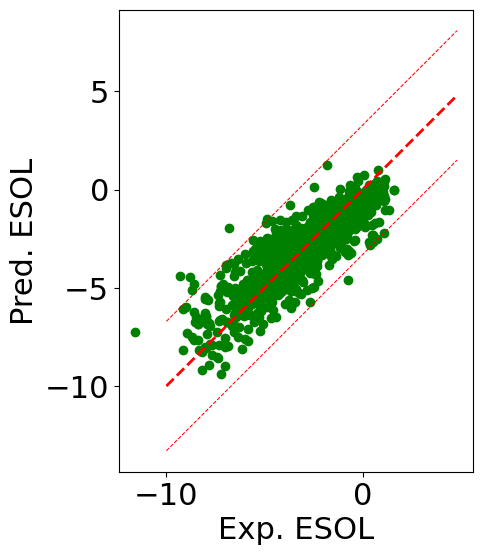

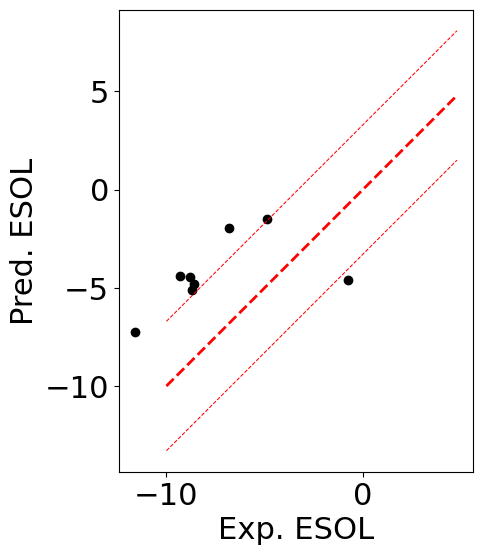

In [20]:
# -------- Plot 1: all molecules --------
plt.figure(figsize=(6,6))

ln = np.arange(-10, 5, 0.2)

plt.plot(ln, ln, 'r--', linewidth=2)
plt.plot(ln, ln+n*sdr, 'r--', linewidth=0.75)
plt.plot(ln, ln-n*sdr, 'r--', linewidth=0.75)

plt.scatter(x=fps_xgboost['actual'], y=fps_xgboost['predict'], color='green')

plt.xlabel('Exp. ESOL')
plt.ylabel('Pred. ESOL')

plt.gca().set_aspect('equal', adjustable='box')  # makes axes proportional

plt.savefig("xgboost_esol_all_points.png", dpi=300, bbox_inches="tight")
plt.show()


# -------- Plot 2: outliers --------
plt.figure(figsize=(6,6))

ln = np.arange(-10, 5, 0.2)

plt.plot(ln, ln, 'r--', linewidth=2)
plt.plot(ln, ln+n*sdr, 'r--', linewidth=0.75)
plt.plot(ln, ln-n*sdr, 'r--', linewidth=0.75)

plt.scatter(x=fps_xgboost_outliers['actual'], y=fps_xgboost_outliers['predict'], color='black')

plt.xlabel('Exp. ESOL')
plt.ylabel('Pred. ESOL')

plt.gca().set_aspect('equal', adjustable='box')

plt.savefig("xgboost_esol_outliers.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
fig = plt.gcf()
fig.savefig("xgboost_esol_all_points.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

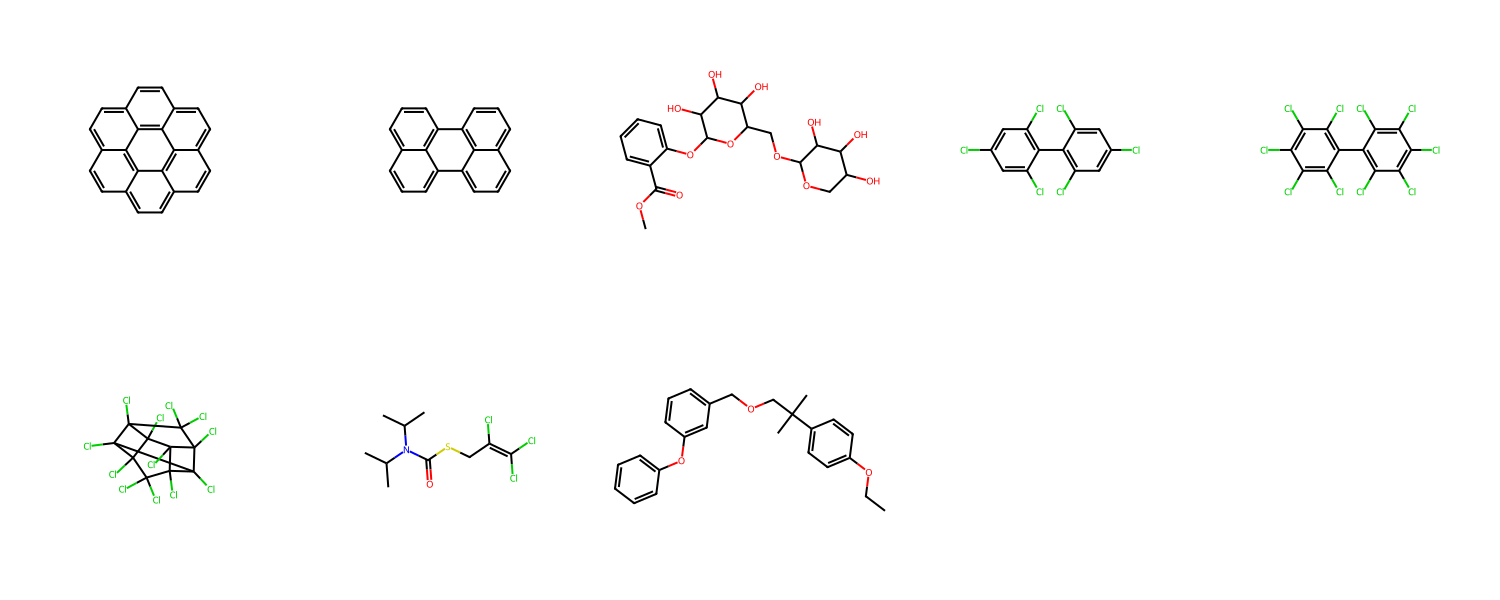

In [22]:
# draw n=3 outlier structure
outliners = [Chem.MolFromSmiles(x) for x in fps_xgboost_outliers['SMILES']]
Draw.MolsToGridImage(outliners, subImgSize=(300,300), molsPerRow=5, maxMols=50)

In [23]:
# n is 2 or 3. Points 2 or 3 sdr away from the prediction line are likely to be outliers
n = 2
fps_xgboost_outliers2 = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]
fps_xgboost_outliers2

,Mol_No,SMILES,actual,predict,residual,std_residual
2,30,Brc1cc(Br)cc(Br)c1,-5.600,-3.103175,2.496825,2.273265
50,296,CCCCC(C)CC,-5.160,-2.706888,2.453112,2.233466
63,351,COc2cnc1cncnc1n2,-0.910,-3.153122,-2.243122,-2.042278
66,367,c3ccc2nc1ccccc1cc2c3,-3.670,-6.027521,-2.357521,-2.146434
69,390,COc1ccc(cc1)C(O)(C2CC2)c3cncnc3,-2.596,-5.015447,-2.419447,-2.202815
...,...,...,...,...,...,...
117,725,CCC(C(CC)c1ccc(O)cc1)c2ccc(O)cc2,-4.430,-2.200369,2.229631,2.029995
126,775,ClC1C(Cl)C(Cl)C(Cl)C(Cl)C1Cl,-4.640,-1.589163,3.050837,2.777672
129,791,CN(C(=O)COc1nc2ccccc2s1)c3ccccc3,-4.873,-2.621960,2.251040,2.049487
165,1025,Cc3cc2nc1c(=O)[nH]c(=O)nc1n(CC(O)C(O)C(O)CO)c2...,-3.685,-0.786985,2.898015,2.638534


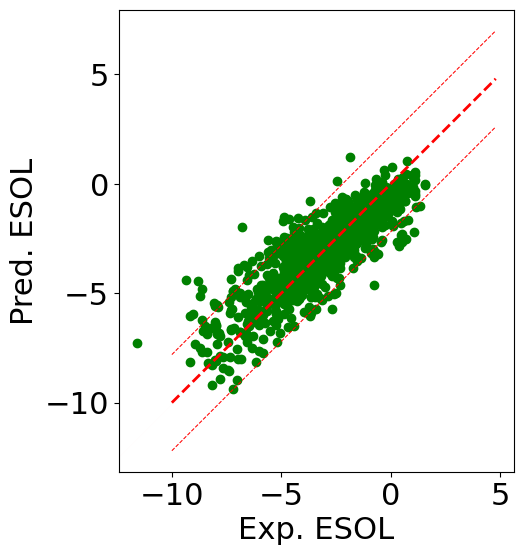

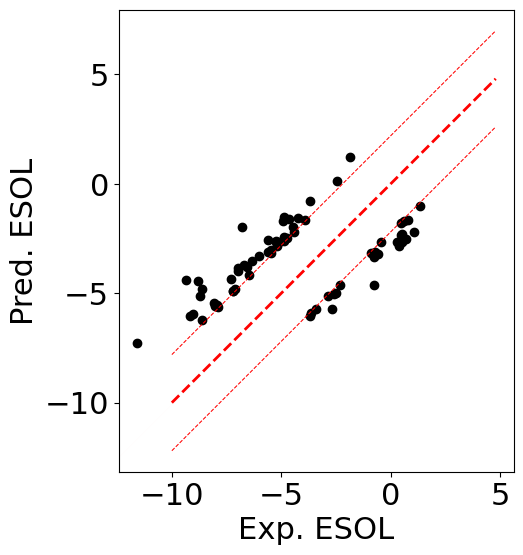

In [24]:
# --- recalculate for ESOL ---
fps_xgboost['residual'] = fps_xgboost['predict'] - fps_xgboost['actual']

sdr_esol = np.sqrt((fps_xgboost['residual']**2).sum() / (len(fps_xgboost) - 2))

fps_xgboost['std_residual'] = fps_xgboost['residual'] / sdr_esol

n = 2
fps_xgboost_outliers = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]

# -------- Plot 1: all molecules --------
plt.figure(figsize=(6,6))

ln = np.arange(-10, 5, 0.2)

plt.plot(ln, ln, 'r--', linewidth=2)
plt.plot(ln, ln + n*sdr_esol, 'r--', linewidth=0.75)
plt.plot(ln, ln - n*sdr_esol, 'r--', linewidth=0.75)

plt.scatter(x=fps_xgboost['actual'], y=fps_xgboost['predict'], color='green')

plt.xlabel('Exp. ESOL')
plt.ylabel('Pred. ESOL')

plt.gca().set_aspect('equal', adjustable='box')

plt.savefig("xgboost_esol_n2_all_points.png", dpi=300, bbox_inches="tight")
plt.show()


# -------- Plot 2: outliers --------
plt.figure(figsize=(6,6))

plt.plot(ln, ln, 'r--', linewidth=2)
plt.plot(ln, ln + n*sdr_esol, 'r--', linewidth=0.75)
plt.plot(ln, ln - n*sdr_esol, 'r--', linewidth=0.75)

plt.scatter(x=fps_xgboost_outliers['actual'],
            y=fps_xgboost_outliers['predict'],
            color='black')

plt.xlabel('Exp. ESOL')
plt.ylabel('Pred. ESOL')

plt.gca().set_aspect('equal', adjustable='box')

plt.savefig("xgboost_esol_n2_outliers.png", dpi=300, bbox_inches="tight")
plt.show()

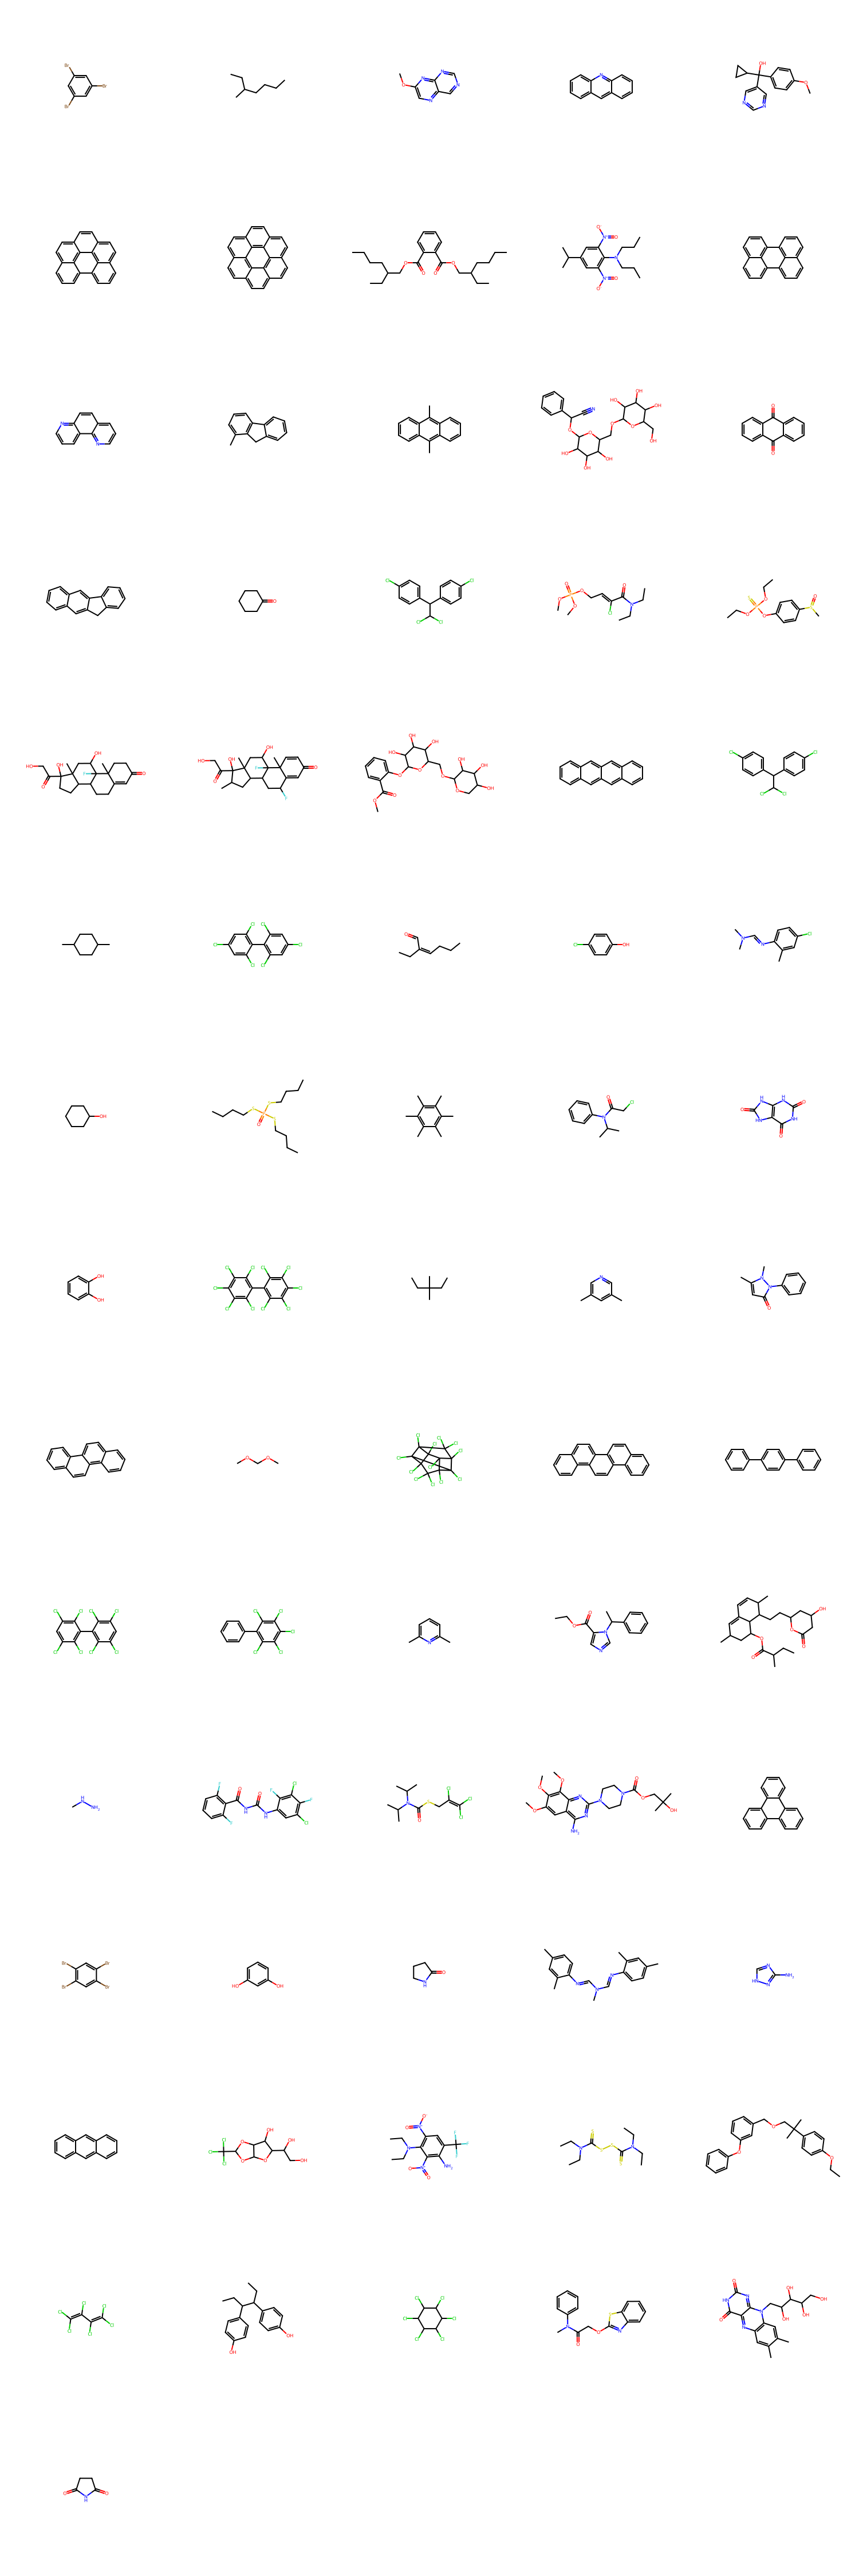

In [25]:
# draw n=2 outlier structure
outliners2 = [Chem.MolFromSmiles(x) for x in fps_xgboost_outliers2['SMILES']]
Draw.MolsToGridImage(outliners2, subImgSize=(300,300), molsPerRow=5, maxMols=100)

In [26]:
# save outliers (n=2) info to a csv file
fps_xgboost_outliers2.to_csv('fps_xgboost_esol_outliers2.csv')

In [27]:
from rdkit.Chem import Descriptors
gpHSP_data = pd.read_csv(r'/Users/favour/Desktop/untitled folder/dataset/esol.csv')
mol_smiles = gpHSP_data['SMILES']

# calculate molecular weight of the full dataset
molwt = [(Descriptors.ExactMolWt(Chem.MolFromSmiles(x))) for x in gpHSP_data['SMILES']]
np_molwt = np.asarray(molwt)

# calculate molecular weight of outliers
molwt_outliers2 = [(Descriptors.ExactMolWt(Chem.MolFromSmiles(x))) for x in fps_xgboost_outliers2['SMILES']]
np_molwt_outliers2 = np.asarray(molwt_outliers2)

# Compare average molecular weight for full data and outliers
print(np.average(np_molwt))
print(np.average(np_molwt_outliers2))

204.1519488730402
252.95335778132394


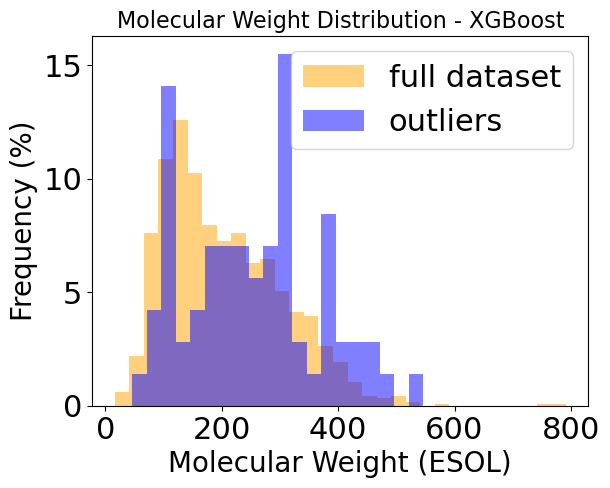

In [28]:
# plit molecular weight distribution for the full dataset and the outliers
bin_width = 25
df = pd.DataFrame(np_molwt, columns = ["full dataset"])
df2 = pd.DataFrame(np_molwt_outliers2, columns = ["outliers"])

ax = df.plot.hist(bins=(np.arange(min(molwt), max(molwt)+bin_width, bin_width)), alpha=0.5, color='orange', weights=np.ones_like(df.index) *100/ len(df))
df2.plot(kind='hist', bins=(np.arange(min(molwt_outliers2), max(molwt_outliers2)+bin_width, bin_width)), alpha=0.5, color='blue', weights=np.ones_like(df2.index) *100 /len(df2), ax=ax)
ax.set_xlabel("Molecular Weight (ESOL)", size=20)
ax.set_ylabel("Frequency (%)", size=20)
ax.set_title("Molecular Weight Distribution - XGBoost", size=16)
plt.show()